In [87]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

In [88]:
df = pd.read_csv("APL_Logistics.csv", encoding="latin1")

# Data Understanding & Cleaning

In [89]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Order Region,Order State,Order Status,Product Name,Product Price,Shipping Mode
0,DEBIT,6,4,159.69,472.45,Late delivery,1,9,Cardio Equipment,Brownsville,...,5,499.95,472.45,159.69,South Asia,Maharashtra,COMPLETE,Nike Men's Free 5.0+ Running Shoe,99.99,Standard Class
1,DEBIT,4,4,48.71,167.96,Shipping on time,0,29,Shop By Sport,Littleton,...,5,199.95,167.96,48.71,Central America,Cortés,ON_HOLD,Under Armour Girls' Toddler Spine Surge Runni,39.99,Standard Class
2,DEBIT,4,4,87.36,181.99,Shipping on time,0,48,Water Sports,Littleton,...,1,199.99,181.99,87.36,Central America,Cortés,ON_HOLD,Pelican Sunstream 100 Kayak,199.99,Standard Class
3,DEBIT,6,4,-41.89,175.99,Late delivery,1,48,Water Sports,Littleton,...,1,199.99,175.99,-41.89,East of USA,Nueva York,COMPLETE,Pelican Sunstream 100 Kayak,199.99,Standard Class
4,DEBIT,6,4,10.00,40.00,Late delivery,1,24,Women's Apparel,Littleton,...,1,50.00,40.00,10.00,East of USA,Nueva York,COMPLETE,Nike Men's Dri-FIT Victory Golf Polo,50.00,Standard Class


In [90]:
df.shape

(180519, 40)

In [91]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Fname', 'Customer Id', 'Customer Lname',
       'Customer Segment', 'Customer State', 'Customer Street',
       'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude',
       'Longitude', 'Market', 'Order City', 'Order Country',
       'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Product Name', 'Product Price', 'Shipping Mode'],
      dtype='object')

In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  object 
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  object 
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  object 
 9   Customer City                  180519 non-null  object 
 10  Customer Country               180519 non-null  object 
 11  Customer Fname                 180519 non-null  object 
 12  Customer Id                   

In [93]:
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Customer Zipcode,Department Id,Latitude,...,Order Customer Id,Order Item Discount,Order Item Discount Rate,Order Item Product Price,Order Item Profit Ratio,Order Item Quantity,Sales,Order Item Total,Order Profit Per Order,Product Price
count,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180516.000000,180519.000000,180519.000000,...,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000,180519.000000
mean,3.497654,2.931847,21.974989,183.107607,0.548291,31.851451,6691.379495,35921.126914,5.443460,29.719955,...,6691.379495,20.664741,0.101668,141.232547,0.120647,2.127638,203.772092,183.107607,21.974989,141.232547
std,1.623722,1.374449,104.433526,120.043668,0.497664,15.640064,4162.918106,37542.461122,1.629246,9.813646,...,4162.918106,21.800901,0.070415,139.732489,0.466796,1.453451,132.273075,120.043668,104.433526,139.732489
min,0.000000,0.000000,-4274.980000,7.490000,0.000000,2.000000,1.000000,603.000000,2.000000,-33.937553,...,1.000000,0.000000,0.000000,9.990000,-2.750000,1.000000,9.990000,7.490000,-4274.980000,9.990000
25%,2.000000,2.000000,7.000000,104.380000,0.000000,18.000000,3258.500000,725.000000,4.000000,18.265432,...,3258.500000,5.400000,0.040000,50.000000,0.080000,1.000000,119.980000,104.380000,7.000000,50.000000
50%,3.000000,4.000000,31.520000,163.990000,1.000000,29.000000,6457.000000,19380.000000,5.000000,33.144863,...,6457.000000,14.000000,0.100000,59.990000,0.270000,1.000000,199.920000,163.990000,31.520000,59.990000
75%,5.000000,4.000000,64.800000,247.400000,1.000000,45.000000,9779.000000,78207.000000,7.000000,39.279617,...,9779.000000,29.990000,0.160000,199.990000,0.360000,3.000000,299.950000,247.400000,64.800000,199.990000
max,6.000000,4.000000,911.800000,1939.990000,1.000000,76.000000,20757.000000,99205.000000,12.000000,48.781933,...,20757.000000,500.000000,0.250000,1999.990000,0.500000,5.000000,1999.990000,1939.990000,911.800000,1999.990000


In [94]:
df.isnull().sum()

Type                             0
Days for shipping (real)         0
Days for shipment (scheduled)    0
Benefit per order                0
Sales per customer               0
Delivery Status                  0
Late_delivery_risk               0
Category Id                      0
Category Name                    0
Customer City                    0
Customer Country                 0
Customer Fname                   0
Customer Id                      0
Customer Lname                   8
Customer Segment                 0
Customer State                   0
Customer Street                  0
Customer Zipcode                 3
Department Id                    0
Department Name                  0
Latitude                         0
Longitude                        0
Market                           0
Order City                       0
Order Country                    0
Order Customer Id                0
Order Item Discount              0
Order Item Discount Rate         0
Order Item Product P

In [95]:
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Customer Lname      8
Customer Zipcode    3
dtype: int64

In [96]:
df.duplicated().sum()

0

In [97]:
df.drop_duplicates(inplace=True)

# Check Target Distribution

In [98]:
df["Late_delivery_risk"].value_counts()

Late_delivery_risk
1    98977
0    81542
Name: count, dtype: int64

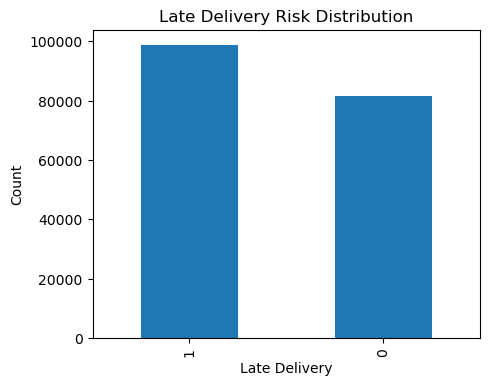

In [99]:
df["Late_delivery_risk"].value_counts().plot(kind = "bar", figsize = (5,4))

plt.title("Late Delivery Risk Distribution")
plt.xlabel("Late Delivery")
plt.ylabel("Count")
plt.show()

# Identify Numerical & Categorical Features

In [100]:
categorical_columns = df.select_dtypes(include="object").columns

numerical_columns = df.select_dtypes(exclude="object").columns

print("Categorical:", len(categorical_columns))
print("Numerical:", len(numerical_columns))

Categorical: 19
Numerical: 21


In [101]:
drop_columns = [
    "Customer Fname",
    "Customer Lname",
    "Customer Street",
    "Delivery Status"
]

df = df.drop(columns=drop_columns)

# Exploratory Data Analysis (EDA)
# 1.Which shipping mode has the highest delay rate?
# 2.Which market has the highest risk?
# 3.Which customer segment experiences more delays?
# 4.Does order quantity increase delay risk?
# 5.Which regions should operations teams prioritize?


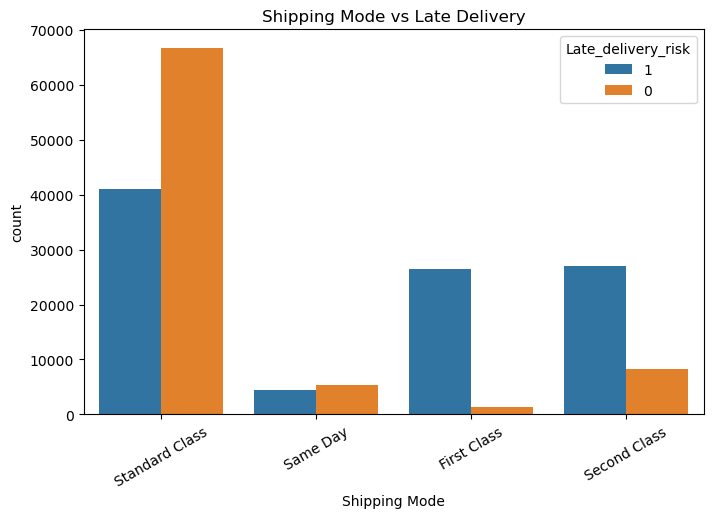

In [105]:
import seaborn as sns
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Shipping Mode",
    hue="Late_delivery_risk"
)

plt.xticks(rotation=30)
plt.title("Shipping Mode vs Late Delivery")
plt.show()

In [106]:
print(df.columns.tolist())

['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Id', 'Customer Segment', 'Customer State', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Product Name', 'Product Price', 'Shipping Mode']


# Customer Segment vs Late Delivery

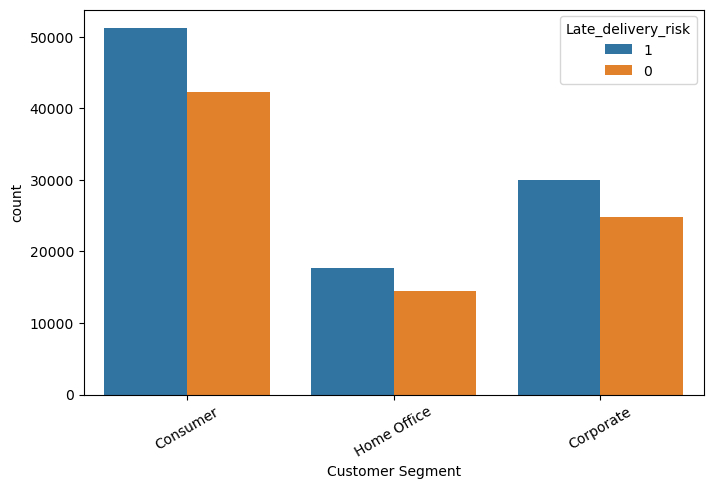

In [107]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Customer Segment",
    hue="Late_delivery_risk"
)

plt.xticks(rotation=30)
plt.show()

In [108]:
df["Late_delivery_risk"] = df["Late_delivery_risk"].astype(str)

# Market vs Late Delivery

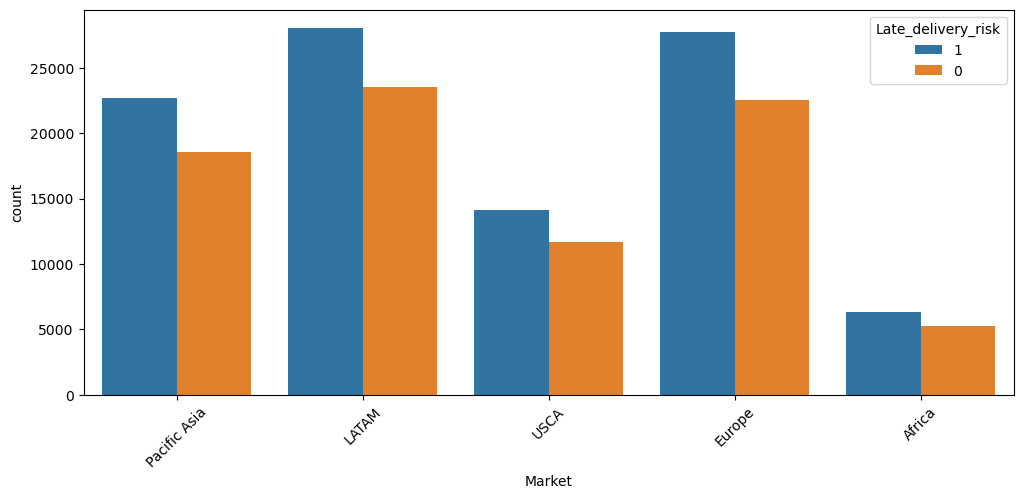

In [109]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Market",
    hue="Late_delivery_risk"
)

plt.xticks(rotation=45)
plt.show()

# Order Region vs Late Delivery

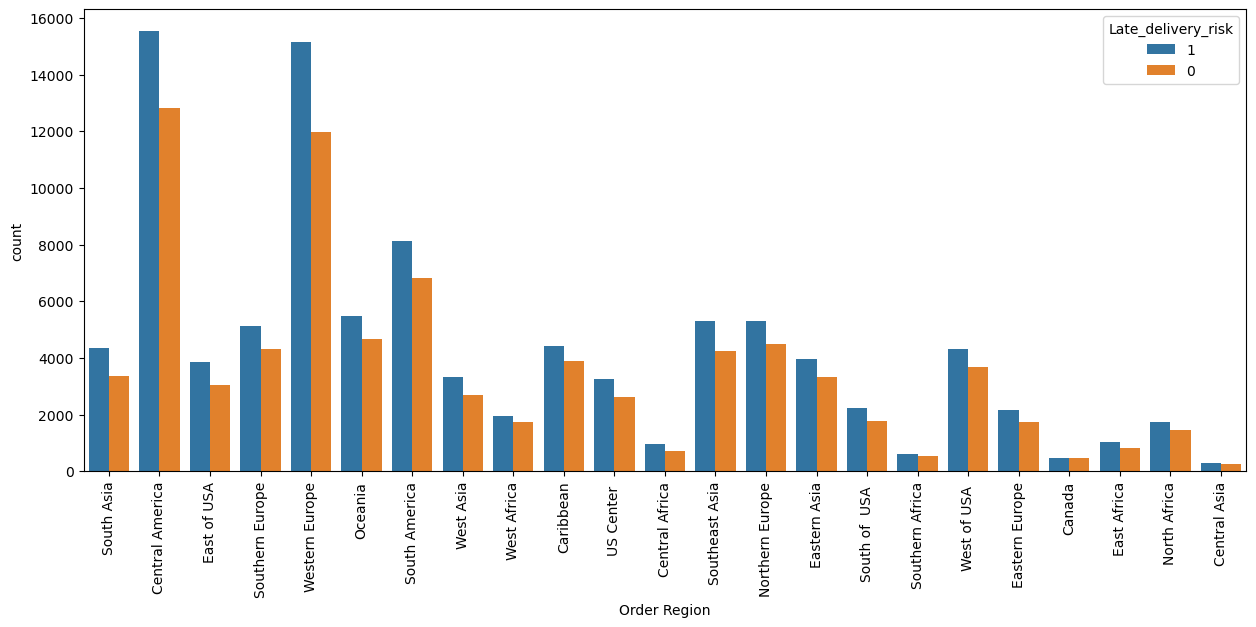

In [110]:
plt.figure(figsize=(15,6))

sns.countplot(
    data=df,
    x="Order Region",
    hue="Late_delivery_risk"
)

plt.xticks(rotation=90)
plt.show()

# Distribution of Sales

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


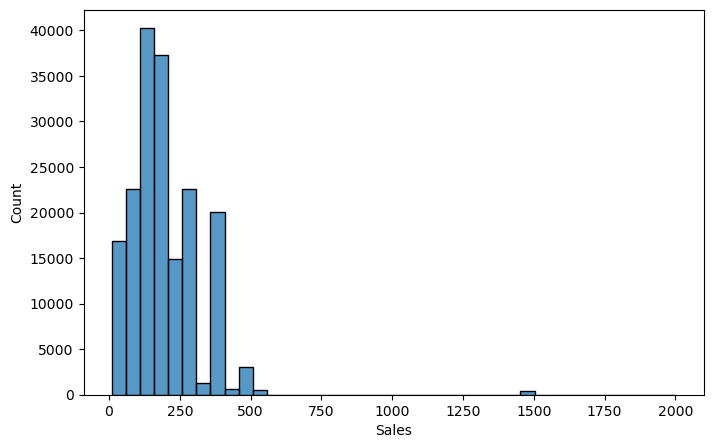

In [111]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sales"], bins=40)

plt.show()

# Distribution of Profit

C:\Users\DELL\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


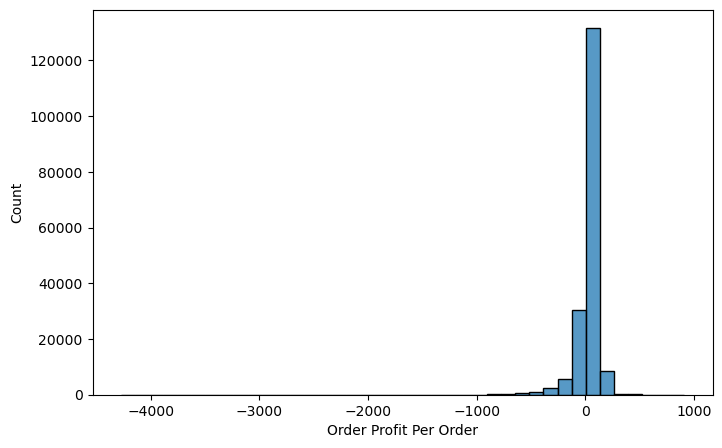

In [112]:
plt.figure(figsize=(8,5))

sns.histplot(df["Order Profit Per Order"], bins=40)

plt.show()

# Correlation Heatmap

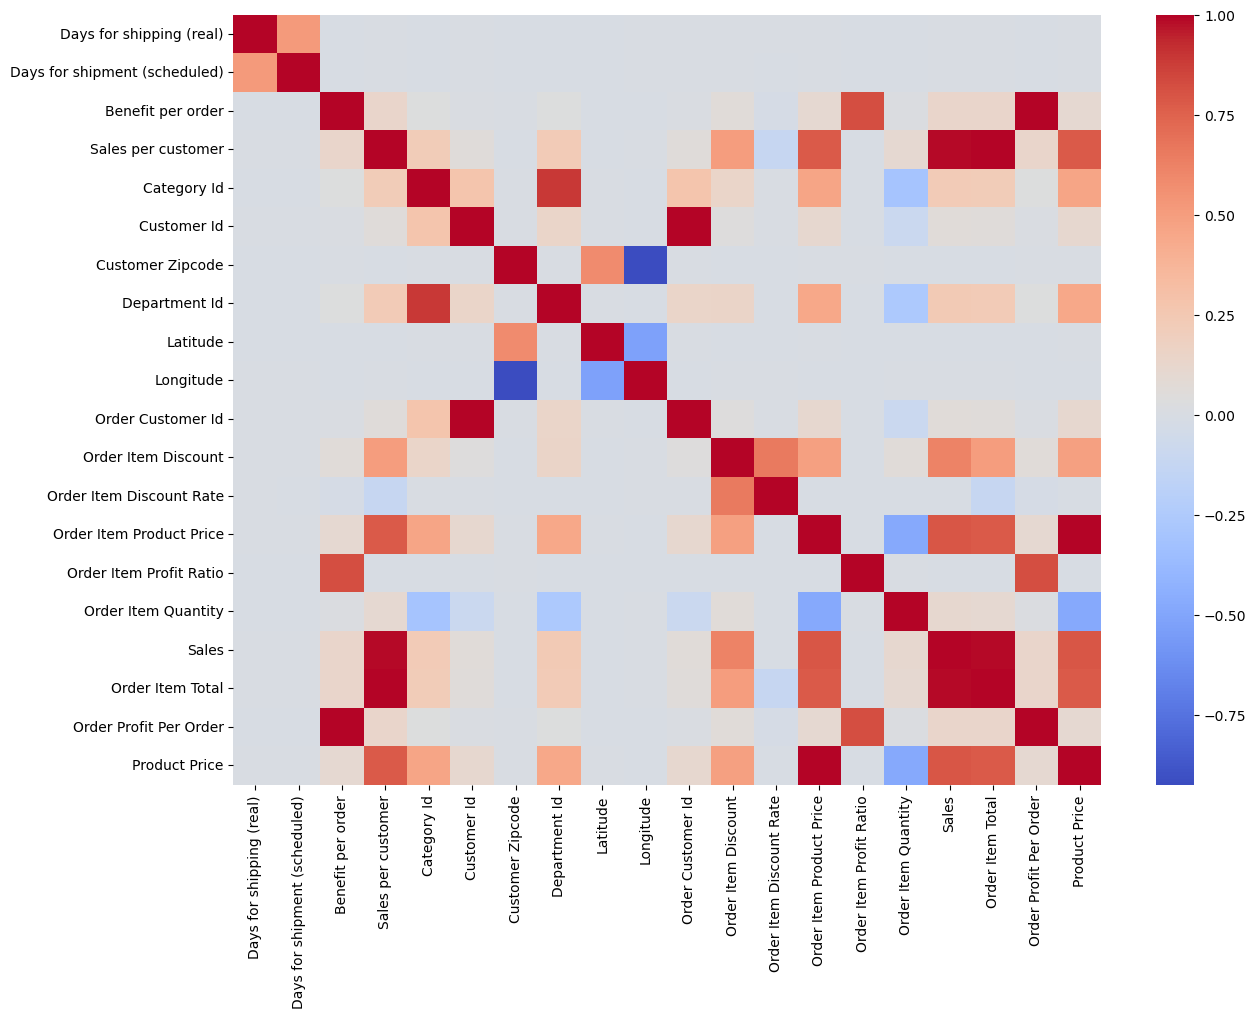

In [113]:
plt.figure(figsize=(14,10))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()

# Feature Engineering

In [114]:
#Shipping Pressure Index
df["Shipping_Pressure"] = (
    df["Order Item Quantity"] /
    df["Days for shipment (scheduled)"]
)

In [115]:
#Profit Margin
df["Profit_Margin"] = (
    df["Order Profit Per Order"] /
    df["Sales"]
)

In [116]:
#Discount Percentage
df["Discount_Percentage"] = (
    df["Order Item Discount Rate"] * 100
)

In [117]:
#Order Value Per Item
df["Average_Item_Value"] = (
    df["Order Item Total"] /
    df["Order Item Quantity"]
)

# Data Preprocessing

In [118]:
drop_cols = [
    "Customer Fname",
    "Customer Lname",
    "Customer Email",
    "Customer Password",
    "Customer Street",
    "Product Description",
    "Product Image",
    "Order Zipcode",
    "Delivery Status"
]

df = df.drop(columns=drop_cols, errors="ignore")

In [180]:
#Separate Features and Target
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"].astype(int)

In [181]:
#Identify Numerical and Categorical Columns
cat_cols = X.select_dtypes(include="object").columns.tolist()

num_cols = X.select_dtypes(exclude="object").columns.tolist()

print(len(cat_cols), len(num_cols))

14 23


In [182]:
#Build the Preprocessing Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

In [183]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [184]:
#Build the First Model (Logistic Regression)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [134]:
nan_cols = X_train.columns[X_train.isnull().any()]

for col in nan_cols:
    print(col, X_train[col].isnull().sum())

Customer Zipcode 3


In [135]:
df = df.dropna(subset=["Customer Zipcode"])

In [136]:
df["Customer Zipcode"].isnull().sum()

0

In [137]:
X = df.drop("Late_delivery_risk", axis=1)
y = df["Late_delivery_risk"]

In [138]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [139]:
lr_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

# Make Predictions

In [185]:
y_pred = lr_model.predict(X_test)
y_prob = lr_model.predict_proba(X_test)[:,1]

In [186]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.714103700421006
Precision: 0.7867780602978569
Recall   : 0.6564962618710851
F1 Score : 0.7157570083163518
ROC AUC  : 0.7821280494945921


# Interpretation for Your Report

You can write:

Logistic Regression was selected as the baseline classification model due to its simplicity and interpretability. The model achieved an accuracy of 71.41% with an ROC-AUC score of 78.21%. While it provides a solid baseline, its recall of 65.65% indicates that some delayed deliveries remain undetected. This motivates the use of more advanced ensemble models such as Random Forest and XGBoost to improve predictive performance.

In [188]:
#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [190]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, rf_pred))
print("Precision:", precision_score(y_test, rf_pred))
print("Recall   :", recall_score(y_test, rf_pred))
print("F1 Score :", f1_score(y_test, rf_pred))
print("ROC AUC  :", roc_auc_score(y_test, rf_prob))

Accuracy : 0.766175493020164
Precision: 0.8730941114616193
Recall   : 0.671095170741564
F1 Score : 0.7588826687992688
ROC AUC  : 0.8730768162582353


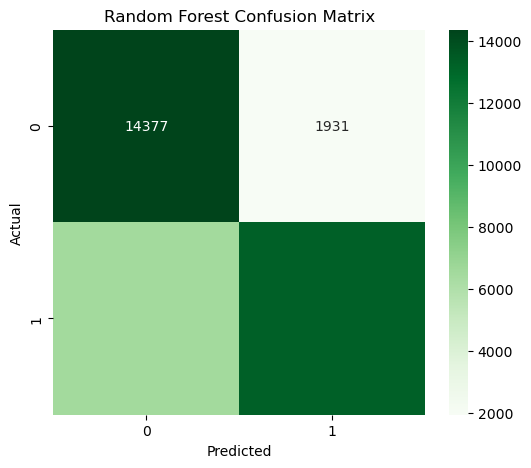

In [191]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()


# Import XGBoost

In [192]:
pip install xgboost


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.2/101.7 MB 4.1 MB/s eta 0:00:25
   ---------------------------------------- 0.3/101.7 MB 3.3 MB/s eta 0:00:32
   ---------------------------------------- 0.4/101.7 MB 3.1 MB/s eta 0:00:33
   ---------------------------------------- 0.7/101.7 MB 3.5 MB/s eta 0:00:29
   ---------------------------------------- 0.8/101.7 MB 3.6 MB/s eta 0:00:28
   ---------------------------------------- 0.9/101.7 MB 3.4 MB/s eta 0:00:30
   ---------------------------------------- 0.9/101.7 MB 2.8 MB/s eta 0:00:37
   ---------------------------------------- 0.9/101.7 MB 2.8 MB/s eta 0:00:37
   ---------------------------------------- 0.9/101.7 MB 2.3 MB/s eta 0:00:43
   ---------------------------------------- 1.2/101.7 MB 2.8 MB/s eta 0:00:36
    --------------------------------------- 1.5/101.7 MB 3.0 MB/s eta 0:00:34
    --------------------------------------- 1.6/101.7 MB 2.9 MB/s eta 

In [193]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [194]:
#xgboost Model
xgb_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [205]:
#Make prediction 
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [196]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

print("Accuracy :", accuracy_score(y_test, xgb_pred))
print("Precision:", precision_score(y_test, xgb_pred))
print("Recall   :", recall_score(y_test, xgb_pred))
print("F1 Score :", f1_score(y_test, xgb_pred))
print("ROC AUC  :", roc_auc_score(y_test, xgb_prob))

Accuracy : 0.7035231553290494
Precision: 0.8511509346516298
Recall   : 0.5566276015356638
F1 Score : 0.6730804471321239
ROC AUC  : 0.7639014634952255


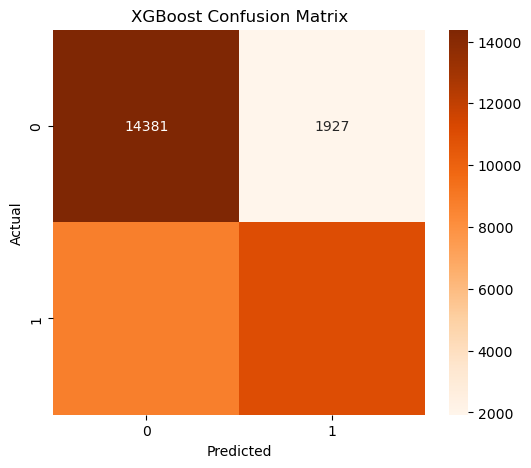

In [197]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

# Model Comparison Table

In [198]:
comparison = {
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        0.7141,
        0.7662,
        None  # Replace with your XGBoost accuracy
    ],
    "Precision": [
        0.7868,
        0.8731,
        None
    ],
    "Recall": [
        0.6565,
        0.6711,
        None
    ],
    "F1 Score": [
        0.7158,
        0.7589,
        None
    ],
    "ROC AUC": [
        0.7821,
        0.8731,
        None
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.7141,0.7868,0.6565,0.7158,0.7821
1,Random Forest,0.7662,0.8731,0.6711,0.7589,0.8731
2,XGBoost,NaN,NaN,NaN,NaN,NaN


In [199]:
#train the xgboost
import xgboost
print(xgboost.__version__)

3.2.0


# Feature Importance

In [210]:
rf = rf_model.named_steps["classifier"]

feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
5670,cat__Shipping Mode_Standard Class,0.056853
0,num__Days for shipment (scheduled),0.049932
5667,cat__Shipping Mode_First Class,0.044577
22,num__Shipping_Pressure,0.025485
9,num__Order Customer Id,0.023481
4,num__Customer Id,0.023346
7,num__Latitude,0.023180
8,num__Longitude,0.021638
19,num__Profit_Margin,0.020637
1,num__Benefit per order,0.020506


# Business Insights

Shipping mode is the strongest operational driver of late delivery.
Scheduled shipping duration has a major impact on delivery risk.
Shipping Pressure (your engineered feature) improves predictive performance by capturing workload relative to available shipping time.
Geographic factors (latitude and longitude) influence the likelihood of delays.
Financial features such as Profit Margin and Order Profit Per Order have a moderate impact.

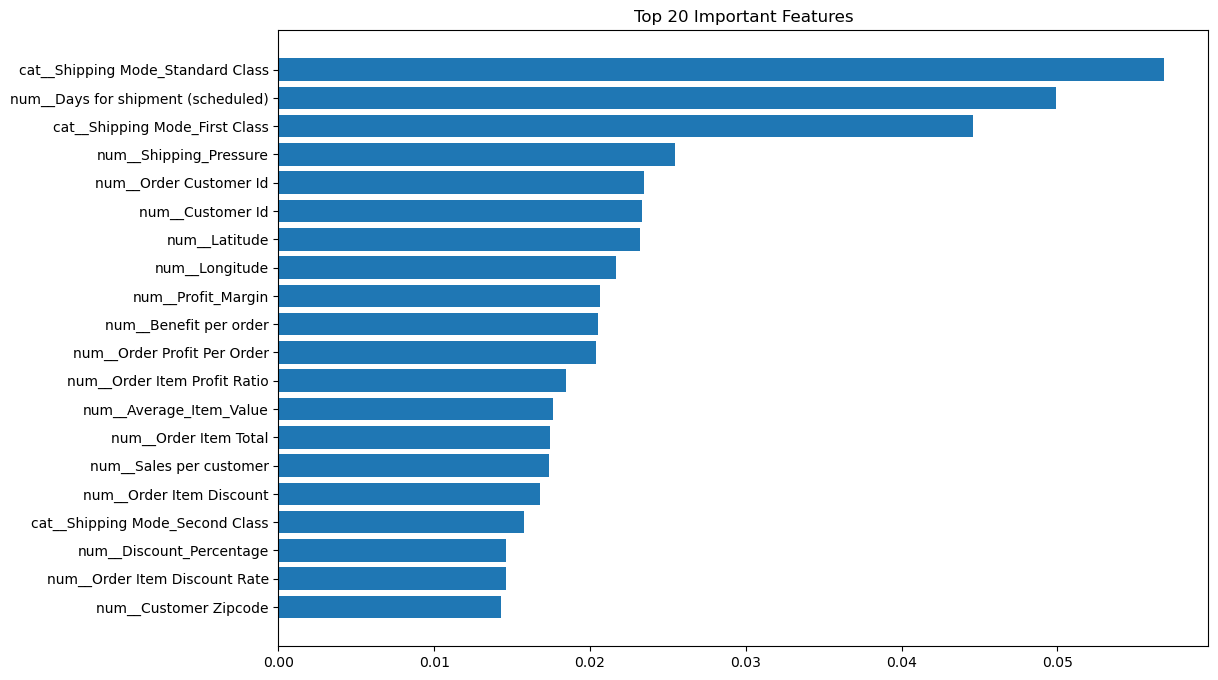

In [211]:
import matplotlib.pyplot as plt

top20 = importance.head(20)

plt.figure(figsize=(12,8))
plt.barh(top20["Feature"], top20["Importance"])
plt.gca().invert_yaxis()

plt.title("Top 20 Important Features")
plt.show()

In [212]:
import joblib

joblib.dump(rf_model, "late_delivery_risk_model.pkl")

['late_delivery_risk_model.pkl']

In [216]:
import os

os.listdir()

['.anaconda',
 '.android',
 '.codex',
 '.conda',
 '.condarc',
 '.continuum',
 '.copilot',
 '.git',
 '.gitconfig',
 '.gradle',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.matplotlib',
 '.ms-ad',
 '.streamlit',
 '.viminfo',
 '.vscode',
 '.vscode-shared',
 '3D Objects',
 'advstat.ipynb',
 'amazon_reviews (1).csv',
 'anaconda3',
 'AndroidStudioProjects',
 'APL_Logistics.csv',
 'app.py',
 'app.py(1)',
 'app2.py',
 'AppData',
 'Application Data',
 'AQI.csv',
 'banana_model.pkl',
 'banana_quality_dataset.csv',
 'Categorical_pre.ipynb',
 'Contacts',
 'Cookies',
 'COV_MATRIX.ipynb',
 'diabetes_data.csv',
 'disaster_pipeline.joblib',
 'disaster_pipeline_v2.joblib',
 'disaster_prediction_model.joblib',
 'Disaster_Prediction_Project',
 'Documents',
 'Downloads',
 'EDA .ipynb',
 'eda _scrap.ipynb',
 'encoders.pkl',
 'Favorites',
 'feature cat selection .ipynb',
 'feature num data.ipynb',
 'fridge_scrap.ipynb',
 'IBA_IOAPDATA_2026-05-02_21-44-09',
 'image data preprocessing.ipynb',
 'inherte

In [215]:
import joblib
joblib.dump(rf_model, "late_delivery_risk_model.pkl")

['late_delivery_risk_model.pkl']

In [217]:
import os
print(os.getcwd())

C:\Users\DELL


In [218]:
import os

size = os.path.getsize("late_delivery_risk_model.pkl") / (1024*1024)
print(f"{size:.2f} MB")

1293.23 MB
